BIOINFORMATICS- Protein Sequence Property Analyzer

In [ ]:
#Install Dependencies
!pip install biopython matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 43.5 MB/s eta 0:00:00


In [ ]:
#Import Libraries
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import matplotlib.pyplot as plt
import json
import re

In [ ]:
#Provide FASTA Input
fasta_data = """>Stable_Hydrophobic_1
VVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV
>Stable_Hydrophilic_1
EEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEE
>Unstable_Protein_1
PESTPESTPESTPESTPESTPESTPESTPESTPESTPESTPESTPEST
>Unstable_Protein_2
GPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGP
>Mixed_Protein_1
MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHF
>Mixed_Protein_2
GAVLILKKKGHHEAELKPLAQSHATKHKIPIKYLEFISEAIIHVLHSR
>Hydrophilic_Rich
KKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKK
>Hydrophobic_Rich
LLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLL
"""

In [ ]:
#FASTA Parser
def read_fasta_from_string(fasta_string):
    sequences = {}
    name = ""
    seq = ""

    for line in fasta_string.split("\n"):
        line = line.strip()
        if line.startswith(">"):
            if name:
                sequences[name] = seq
            name = line[1:]
            seq = ""
        else:
            seq += line

    if name:
        sequences[name] = seq

    return sequences

In [ ]:
#Hydropathy (Sliding Window)
hydropathy_scale = {
    'A': 1.8, 'C': 2.5, 'D': -3.5, 'E': -3.5,
    'F': 2.8, 'G': -0.4, 'H': -3.2, 'I': 4.5,
    'K': -3.9, 'L': 3.8, 'M': 1.9, 'N': -3.5,
    'P': -1.6, 'Q': -3.5, 'R': -4.5, 'S': -0.8,
    'T': -0.7, 'V': 4.2, 'W': -0.9, 'Y': -1.3
}

def sliding_window_hydropathy(sequence, window=5):
    values = []
    for i in range(len(sequence) - window + 1):
        segment = sequence[i:i+window]
        score = sum(hydropathy_scale[aa] for aa in segment) / window
        values.append(score)
    return values

In [ ]:
#Motif Detection
def find_motifs(sequence, motif="N[^P][ST]"):
    return [m.start() for m in re.finditer(motif, sequence)]

In [ ]:
#Protein Analysis
def analyze_protein(sequence):
    protein = ProteinAnalysis(sequence)

    helix, turn, sheet = protein.secondary_structure_fraction()

    return {
        "length": len(sequence),
        "molecular_weight": protein.molecular_weight(),
        "pI": protein.isoelectric_point(),
        "gravy": protein.gravy(),
        "instability_index": protein.instability_index(),
        "secondary_structure": {
            "helix": helix,
            "turn": turn,
            "sheet": sheet
        },
        "hydropathy_profile": sliding_window_hydropathy(sequence),
        "motifs": find_motifs(sequence)
    }

In [ ]:
#Classification Model
def classify_protein(instability_index, gravy):
    if instability_index < 40 and gravy > 0:
        return "Stable & Hydrophobic"
    elif instability_index < 40:
        return "Stable & Hydrophilic"
    else:
        return "Unstable Protein"

In [ ]:
#Visualization
def plot_hydropathy(values, name):
    plt.figure()
    plt.plot(values)
    plt.title(f"Hydropathy Plot - {name}")
    plt.xlabel("Position")
    plt.ylabel("Hydropathy")
    plt.show()


 Analyzing Stable_Hydrophobic_1...
Length: 50
Molecular Weight: 4974.57
Isoelectric Point: 5.49
GRAVY: 4.20
Instability Index: 9.80
Motif Positions: []
Classification: Stable & Hydrophobic


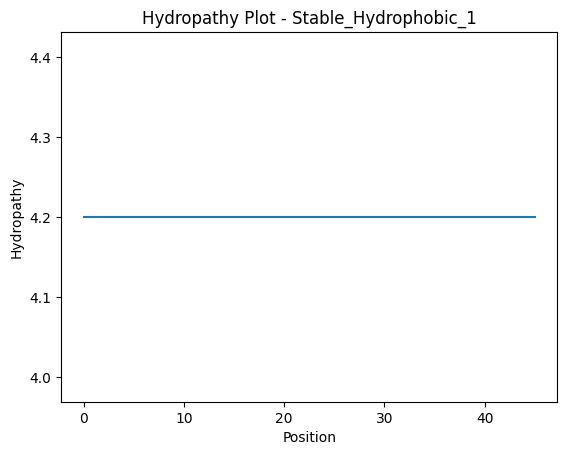


 Analyzing Stable_Hydrophilic_1...
Length: 50
Molecular Weight: 6473.72
Isoelectric Point: 4.05
GRAVY: -3.50
Instability Index: 329.28
Motif Positions: []
Classification: Unstable Protein


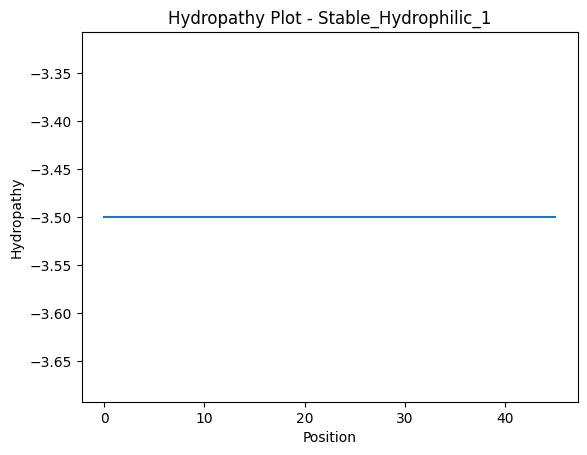


 Analyzing Unstable_Protein_1...
Length: 48
Molecular Weight: 4990.94
Isoelectric Point: 4.05
GRAVY: -1.65
Instability Index: 101.39
Motif Positions: []
Classification: Unstable Protein


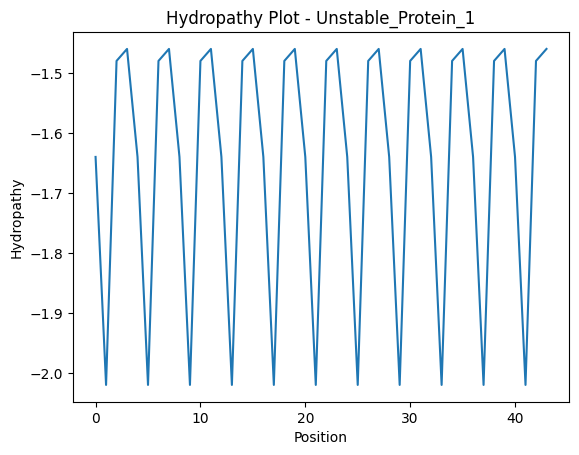


 Analyzing Unstable_Protein_2...
Length: 46
Molecular Weight: 3563.84
Isoelectric Point: 5.53
GRAVY: -1.00
Instability Index: 9.78
Motif Positions: []
Classification: Stable & Hydrophilic


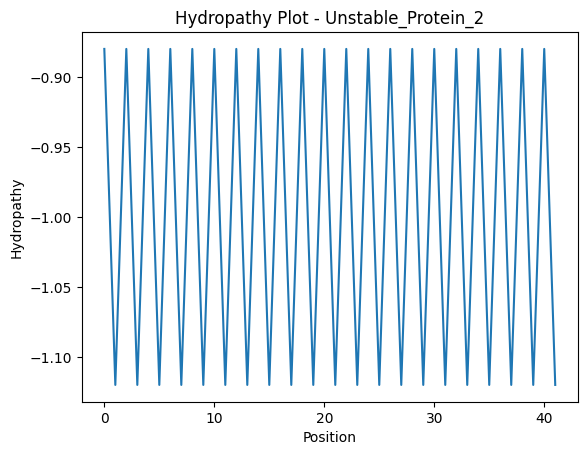


 Analyzing Mixed_Protein_1...
Length: 47
Molecular Weight: 5173.88
Isoelectric Point: 8.14
GRAVY: -0.14
Instability Index: 5.34
Motif Positions: []
Classification: Stable & Hydrophilic


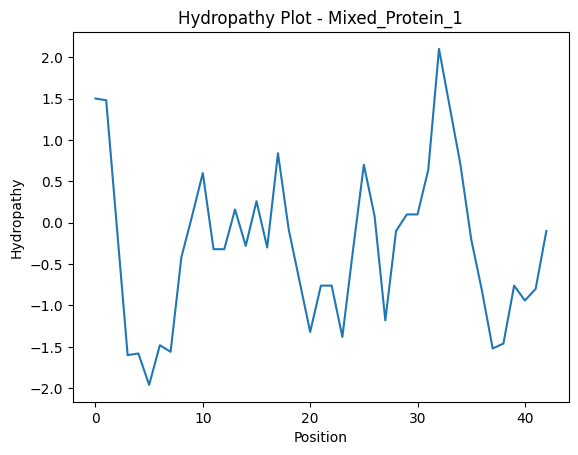


 Analyzing Mixed_Protein_2...
Length: 48
Molecular Weight: 5431.39
Isoelectric Point: 9.78
GRAVY: -0.14
Instability Index: 25.70
Motif Positions: []
Classification: Stable & Hydrophilic


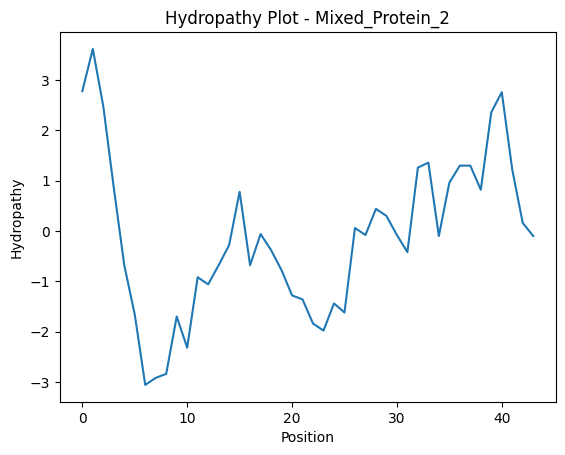


 Analyzing Hydrophilic_Rich...
Length: 48
Molecular Weight: 6170.29
Isoelectric Point: 11.67
GRAVY: -3.90
Instability Index: 9.79
Motif Positions: []
Classification: Stable & Hydrophilic


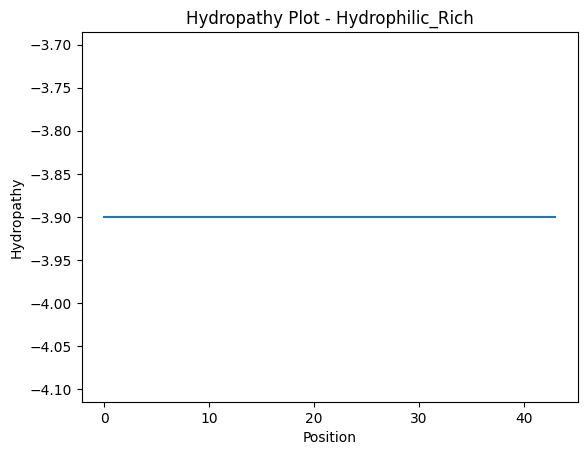


 Analyzing Hydrophobic_Rich...
Length: 48
Molecular Weight: 5449.58
Isoelectric Point: 5.53
GRAVY: 3.80
Instability Index: 9.79
Motif Positions: []
Classification: Stable & Hydrophobic


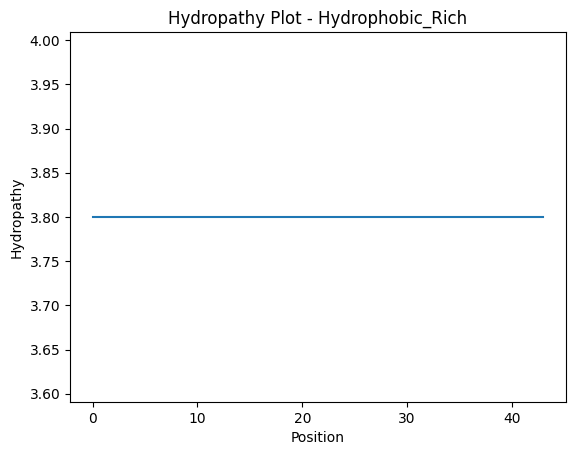

In [ ]:
#Main Execution
sequences = read_fasta_from_string(fasta_data)

all_results = {}

for name, seq in sequences.items():
    print(f"\n Analyzing {name}...")

    result = analyze_protein(seq)

    classification = classify_protein(
        result["instability_index"],
        result["gravy"]
    )

    result["classification"] = classification
    all_results[name] = result

    # Print results
    print(f"Length: {result['length']}")
    print(f"Molecular Weight: {result['molecular_weight']:.2f}")
    print(f"Isoelectric Point: {result['pI']:.2f}")
    print(f"GRAVY: {result['gravy']:.2f}")
    print(f"Instability Index: {result['instability_index']:.2f}")
    print(f"Motif Positions: {result['motifs']}")
    print(f"Classification: {classification}")

    # Plot graph
    plot_hydropathy(result["hydropathy_profile"], name)

this shell give output here itself

In [ ]:
import pandas as pd

# Convert results into table format
table_data = []

for name, result in all_results.items():
    row = {
        "Protein": name,
        "Length": result["length"],
        "Molecular Weight": round(result["molecular_weight"], 2),
        "pI": round(result["pI"], 2),
        "GRAVY": round(result["gravy"], 2),
        "Instability Index": round(result["instability_index"], 2),
        "Helix": round(result["secondary_structure"]["helix"], 2),
        "Turn": round(result["secondary_structure"]["turn"], 2),
        "Sheet": round(result["secondary_structure"]["sheet"], 2),
        "Motifs Found": len(result["motifs"]),
        "Classification": result["classification"]
    }
    table_data.append(row)

# Create DataFrame
df = pd.DataFrame(table_data)

# Display table
df

,Protein,Length,Molecular Weight,pI,GRAVY,Instability Index,Helix,Turn,Sheet,Motifs Found,Classification
0,Stable_Hydrophobic_1,50,4974.57,5.49,4.20,9.80,0.00,0.00,1.00,0,Stable & Hydrophobic
1,Stable_Hydrophilic_1,50,6473.72,4.05,-3.50,329.28,1.00,0.00,0.00,0,Unstable Protein
2,Unstable_Protein_1,48,4990.94,4.05,-1.65,101.39,0.25,0.50,0.25,0,Unstable Protein
3,Unstable_Protein_2,46,3563.84,5.53,-1.00,9.78,0.00,1.00,0.00,0,Stable & Hydrophilic
4,Mixed_Protein_1,47,5173.88,8.14,-0.14,5.34,0.40,0.23,0.36,0,Stable & Hydrophilic
5,Mixed_Protein_2,48,5431.39,9.78,-0.14,25.70,0.46,0.15,0.35,0,Stable & Hydrophilic
6,Hydrophilic_Rich,48,6170.29,11.67,-3.90,9.79,1.00,0.00,0.00,0,Stable & Hydrophilic
7,Hydrophobic_Rich,48,5449.58,5.53,3.80,9.79,1.00,0.00,1.00,0,Stable & Hydrophobic


this shell gives output in file format in the left panel .json format